#### Import all files

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno

In [13]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Data Extraction and Transformation

#### Loaded data of 45 patients from csv 

In [14]:
# the base directory as current working directory
base_directory = '/Users/ajaysimadvay/CGMacros/'  # 'Desktop/Tableau/Datathon-June 2025/CGMacros/CGMacros.csv'
file_paths = []
for i in range(1, 50):
    file_path = os.path.join(base_directory, f'CGMacros-{i:03d}', f'CGMacros-{i:03d}.csv')
    if os.path.exists(file_path):
        file_paths.append(file_path)
    else:
        print(f"There is no record of this participant: {file_path}")
        
def clean_columns(df):
    df.columns = df.columns.str.strip()  # remove whitespace
    # Rename columns Amount Consumed ': 'Amount Consumed'
    if 'Amount Consumed ' in df.columns:
        df.rename(columns={'Amount Consumed ': 'Amount Consumed'}, inplace=True)
    return df

def read_csv_for_all_participant(path):
    df = pd.read_csv(path)
    df = clean_columns(df)
    filename = os.path.basename(path) # 'Desktop/Tableau/Datathon-June 2025/CGMacros/CGMacros.csv'
    participant_id = int((filename.split('-')[1].split('.')[0]).lstrip("0")) # CGMacros - 024 . csv
    df['participantID'] = participant_id
    return df

participant_df = pd.concat(map(read_csv_for_all_participant, file_paths), ignore_index=True)
print(f"Loaded data of {participant_df['participantID'].nunique()} participants.")



There is no record of this participant: /Users/ajaysimadvay/CGMacros/CGMacros-024/CGMacros-024.csv
There is no record of this participant: /Users/ajaysimadvay/CGMacros/CGMacros-025/CGMacros-025.csv
There is no record of this participant: /Users/ajaysimadvay/CGMacros/CGMacros-037/CGMacros-037.csv
There is no record of this participant: /Users/ajaysimadvay/CGMacros/CGMacros-040/CGMacros-040.csv
Loaded data of 45 participants.


In [15]:
print('Display participant Data of all participants :\n')
participant_df.head(2)

Display participant Data of all participants :



,Unnamed: 0,Timestamp,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path,participantID,Steps,RecordIndex,Intensity,Sugar
0,0.0,2020-05-01 10:30:00,84.000000,NaN,56.0,1.0484,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
1,1.0,2020-05-01 10:31:00,84.133333,NaN,56.0,1.0484,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


### Dropping Column

In [16]:
participant_df.drop(columns=['Unnamed: 0'] , axis=1 ,inplace =True)

### Read other remaining  files.

In [17]:
def other_files_read_csv(filename):
    path = os.path.join(base_directory, filename)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded data from {filename}")
        #rename Subject to participantID  
        if 'subject' in df.columns:
            df.rename(columns={'subject': 'participantID'}, inplace=True)
        return df
    else:
        print(f"Missing {filename}, creating empty DataFrame")
        return pd.DataFrame()


# load other remaining  files
bio_df = other_files_read_csv('bio.csv')
gut_df = other_files_read_csv('gut_health_test.csv')
microbes_df = other_files_read_csv('microbes.csv')

Loaded data from bio.csv
Loaded data from gut_health_test.csv
Loaded data from microbes.csv


In [18]:
print('Display bio Data of participant : \n')
bio_df.head(2)

Display bio Data of participant : 



,participantID,Age,Gender,BMI,Body weight,Height,Self-identify,A1c PDL (Lab),Fasting GLU - PDL (Lab),Insulin,...,LDL (Cal),VLDL (Cal),Cho/HDL Ratio,Collection time PDL (Lab),#1 Contour Fingerstick GLU,Time (t),#2 Contour Fingerstick GLU,Time (t).1,#3 Contour Fingerstick GLU,Time (t).2
0,1,27,M,22.265239,133.8,65.0,Hispanic/Latino,5.4,91,2.5,...,130,13,2.9,11:06:00 AM,89,9:40,73,12:11,81,13:18
1,2,49,F,30.946742,169.2,62.0,Hispanic/Latino,5.5,93,14.8,...,78,12,2.0,7:38:00 AM,91,7:52,123,9:21,80,10:22


In [19]:
print('Display gut Data of participant :\n')
gut_df.head(2)

Display gut Data of participant :



,participantID,Gut Lining Health,LPS Biosynthesis Pathways,"Biofilm, Chemotaxis, and Virulence Pathways",TMA Production Pathways,Ammonia Production Pathways,Metabolic Fitness,Active Microbial Diversity,Butyrate Production Pathways,Flagellar Assembly Pathways,...,Inflammatory Activity,Gut Microbiome Health,Digestive Efficiency,Protein Fermentation,Gas Production,Methane Gas Production Pathways,Sulfide Gas Production Pathways,Oxalate Metabolism Pathways,Salt Stress Pathways,Microbiome-Induced Stress
0,1,2.0,2.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,...,2.0,3.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0,2.0
1,2,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,...,2.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0


In [20]:
print('Display microbes Data of participant :\n')
microbes_df.head(2)

Display microbes Data of participant :



,participantID,Abiotrophia defectiva,Abiotrophia sp. HMSC24B09,Acetivibrio ethanolgignens,Acetivibrio ethanolgignens strain ACET-33324,Achromobacter,Acidaminococcus intestini RyC-MR95,Acidaminococcus sp. BV3L6,Acidaminococcus sp. D21,Acidaminococcus sp. HPA0509,...,[Eubacterium] rectale strain T1-815,[Eubacterium] siraeum DSM 15702,[Eubacterium] siraeum strain 2789STDY5834928,[Propionibacterium] namnetense,[Ruminococcus] gnavus ATCC 29149,[Ruminococcus] torques strain 2789STDY5608833,[Ruminococcus] torques strain 2789STDY5608867,[Ruminococcus] torques strain 2789STDY5834841,[Ruminococcus] torques strain 2789STDY5834889,bacterium LF-3
0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
1,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


### Rename columns if needed

Checking columns to rename in all Dataframes

In [21]:
participant_df.columns

Index(['Timestamp', 'Libre GL', 'Dexcom GL', 'HR', 'Calories (Activity)',
       'METs', 'Meal Type', 'Calories', 'Carbs', 'Protein', 'Fat', 'Fiber',
       'Amount Consumed', 'Image path', 'participantID', 'Steps',
       'RecordIndex', 'Intensity', 'Sugar'],
      dtype='object')

In [22]:
gut_df.columns

Index(['participantID', 'Gut Lining Health', 'LPS Biosynthesis Pathways',
       'Biofilm, Chemotaxis, and Virulence Pathways',
       'TMA Production Pathways', 'Ammonia Production Pathways',
       'Metabolic Fitness', 'Active Microbial Diversity',
       'Butyrate Production Pathways', 'Flagellar Assembly Pathways',
       'Putrescine Production Pathways', 'Uric Acid Production Pathways',
       'Bile Acid Metabolism Pathways', 'Inflammatory Activity',
       'Gut Microbiome Health', 'Digestive Efficiency', 'Protein Fermentation',
       'Gas Production', 'Methane Gas Production Pathways',
       'Sulfide Gas Production Pathways', 'Oxalate Metabolism Pathways',
       'Salt Stress Pathways', 'Microbiome-Induced Stress'],
      dtype='object')

In [23]:
microbes_df.columns

Index(['participantID', 'Abiotrophia defectiva ', 'Abiotrophia sp. HMSC24B09 ',
       'Acetivibrio ethanolgignens ',
       'Acetivibrio ethanolgignens strain ACET-33324 ', 'Achromobacter ',
       'Acidaminococcus intestini RyC-MR95 ', 'Acidaminococcus sp. BV3L6 ',
       'Acidaminococcus sp. D21 ', 'Acidaminococcus sp. HPA0509 ',
       ...
       '[Eubacterium] rectale strain T1-815 ',
       '[Eubacterium] siraeum DSM 15702 ',
       '[Eubacterium] siraeum strain 2789STDY5834928 ',
       '[Propionibacterium] namnetense ', '[Ruminococcus] gnavus ATCC 29149 ',
       '[Ruminococcus] torques strain 2789STDY5608833 ',
       '[Ruminococcus] torques strain 2789STDY5608867 ',
       '[Ruminococcus] torques strain 2789STDY5834841 ',
       '[Ruminococcus] torques strain 2789STDY5834889 ', 'bacterium LF-3 '],
      dtype='object', length=1980)

In [24]:
bio_df.columns

Index(['participantID', 'Age', 'Gender', 'BMI', 'Body weight ', 'Height ',
       'Self-identify ', 'A1c PDL (Lab)', 'Fasting GLU - PDL (Lab)',
       'Insulin ', 'Triglycerides', 'Cholesterol', 'HDL', 'Non HDL ',
       'LDL (Cal)', 'VLDL (Cal)', 'Cho/HDL Ratio', 'Collection time PDL (Lab)',
       '#1 Contour Fingerstick GLU', 'Time (t)', ' #2 Contour Fingerstick GLU',
       'Time (t).1', '#3 Contour Fingerstick GLU', 'Time (t).2'],
      dtype='object')

In [25]:
bio_df.rename(columns={'Self-identify ':'Ethnicity',
                   'A1c PDL (Lab)': 'HbA1c',
                   'Fasting GLU - PDL (Lab)':'Fasting Glucose',
                   'Collection time PDL (Lab)':'PDL_Sample_Collection_Time',
                    'Cho/HDL Ratio':'Cho_HDL_Ratio',
                   '#1 Contour Fingerstick GLU':'Glucose_fingerstick_1', 
                   'Time (t)':'Glucose_T1', 
                   ' #2 Contour Fingerstick GLU':'Glucose_fingerstick_2',
                   'Time (t).1':'Glucose_T2',
                   '#3 Contour Fingerstick GLU':'Glucose_fingerstick_3',
                   'Time (t).2':'Glucose_T3',
                   },inplace=True)

In [26]:
print("Display renamed columns only : \n")
bio_df[['Ethnicity','HbA1c','Fasting Glucose','PDL_Sample_Collection_Time','Cho_HDL_Ratio','Glucose_fingerstick_1',
        'Glucose_T1','Glucose_fingerstick_2','Glucose_T2','Glucose_fingerstick_3','Glucose_T3']].head(1)

Display renamed columns only : 



,Ethnicity,HbA1c,Fasting Glucose,PDL_Sample_Collection_Time,Cho_HDL_Ratio,Glucose_fingerstick_1,Glucose_T1,Glucose_fingerstick_2,Glucose_T2,Glucose_fingerstick_3,Glucose_T3
0,Hispanic/Latino,5.4,91,11:06:00 AM,2.9,89,9:40,73,12:11,81,13:18


### Handling  Datatypes and Precisions

In [27]:
participant_df['Libre GL'] = participant_df['Libre GL'].round(2)
participant_df['Calories (Activity)']= participant_df['Calories (Activity)'].round(2)
participant_df[['Libre GL','Calories (Activity)']].head(1)

,Libre GL,Calories (Activity)
0,84.0,1.05


In [28]:
bio_df['BMI'] =  bio_df['BMI'].round(2)
bio_df[['BMI']].head(1)

,BMI
0,22.27


### Handling Missing values and Null records

 Checking null values for all dataframes

In [29]:
participant_df.isnull().sum()

Timestamp                   0
Libre GL                  220
Dexcom GL               57755
HR                      77324
Calories (Activity)     35446
METs                   186502
Meal Type              685874
Calories               685874
Carbs                  685874
Protein                685874
Fat                    685874
Fiber                  685875
Amount Consumed        685938
Image path             684383
participantID               0
Steps                  681925
RecordIndex            687563
Intensity              530870
Sugar                  687541
dtype: int64

#### Display Chart

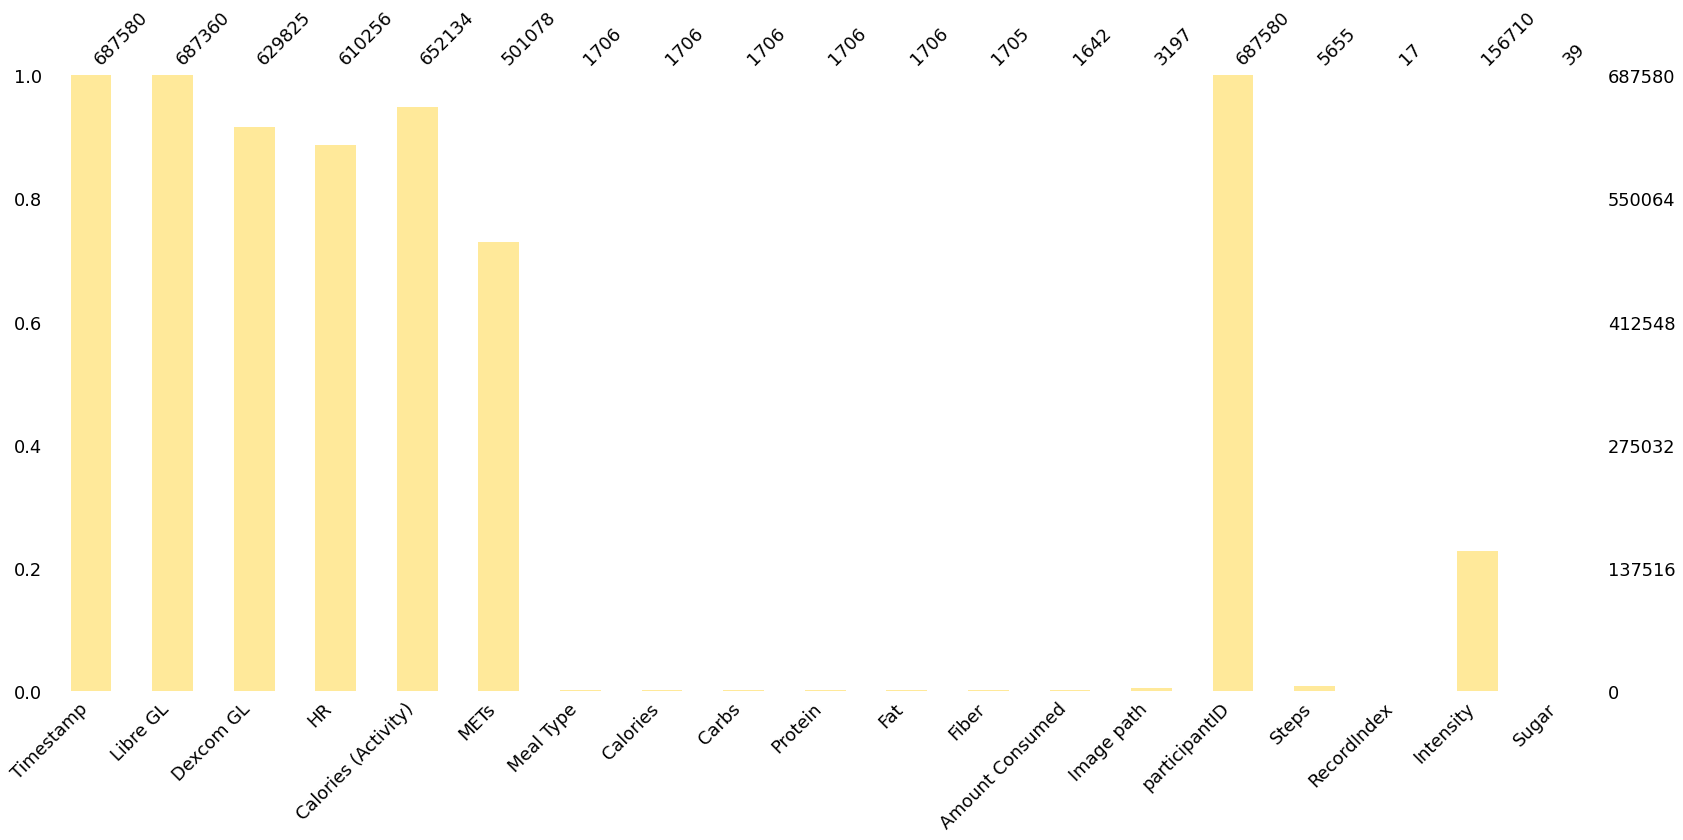

In [30]:
plt.figure(figsize=(8, 2),dpi=80)  # Width=8, Height=4 (adjust as needed)
missingno.bar(participant_df, color='#FFE99A')
plt.show()

In [31]:
bio_df.isnull().sum()

participantID                 0
Age                           0
Gender                        0
BMI                           0
Body weight                   0
Height                        0
Ethnicity                     0
HbA1c                         0
Fasting Glucose               0
Insulin                       0
Triglycerides                 0
Cholesterol                   0
HDL                           0
Non HDL                       0
LDL (Cal)                     0
VLDL (Cal)                    0
Cho_HDL_Ratio                 0
PDL_Sample_Collection_Time    0
Glucose_fingerstick_1         0
Glucose_T1                    0
Glucose_fingerstick_2         0
Glucose_T2                    0
Glucose_fingerstick_3         0
Glucose_T3                    0
dtype: int64

In [32]:
gut_df.isnull().sum()

participantID                                  0
Gut Lining Health                              5
LPS Biosynthesis Pathways                      5
Biofilm, Chemotaxis, and Virulence Pathways    5
TMA Production Pathways                        5
Ammonia Production Pathways                    5
Metabolic Fitness                              5
Active Microbial Diversity                     5
Butyrate Production Pathways                   5
Flagellar Assembly Pathways                    5
Putrescine Production Pathways                 5
Uric Acid Production Pathways                  5
Bile Acid Metabolism Pathways                  5
Inflammatory Activity                          5
Gut Microbiome Health                          5
Digestive Efficiency                           5
Protein Fermentation                           5
Gas Production                                 5
Methane Gas Production Pathways                5
Sulfide Gas Production Pathways                5
Oxalate Metabolism P

In [33]:
microbes_df.isnull().sum()

participantID                                     0
Abiotrophia defectiva                             1
Abiotrophia sp. HMSC24B09                         1
Acetivibrio ethanolgignens                        1
Acetivibrio ethanolgignens strain ACET-33324      1
                                                 ..
[Ruminococcus] torques strain 2789STDY5608833     1
[Ruminococcus] torques strain 2789STDY5608867     1
[Ruminococcus] torques strain 2789STDY5834841     1
[Ruminococcus] torques strain 2789STDY5834889     1
bacterium LF-3                                    1
Length: 1980, dtype: int64

#### Replacing Null values

<br> Replacing Null by mean value of HR according to participant's recorded values 

In [34]:
mean = (participant_df.groupby('participantID')['HR'].mean()).astype(int)
mean_df = mean.reset_index()
print('Display mean values only :\n')
mean_df.head(2)

Display mean values only :



,participantID,HR
0,1,71
1,2,79


In [35]:
participant_df['HR']= participant_df.groupby('participantID')['HR'].transform(lambda x: x.fillna(x.mean())).astype(int)

In [36]:
# for participant_df= participant_df.loc(parti'HRcipant_df['Unnamed: 0' == 1634.0])	 #7011. id= 1. # id =2 8431 8433
print('Display replace values only :\n')
#df = participant_df.loc[(participant_df['Unnamed: 0'] == 1634.0) & (participant_df['participantID']==1)]
df = participant_df.loc[(participant_df.index == 23163) & (participant_df['participantID']==2)]
df[['participantID','HR']].head(2)



Display replace values only :



,participantID,HR
23163,2,79


In [37]:
fill_rows = gut_df['participantID'].isin([26, 28, 48])
gut_df.loc[fill_rows] = gut_df.loc[fill_rows].fillna(0)

In [38]:
df = gut_df.loc[(fill_rows)]
df

,participantID,Gut Lining Health,LPS Biosynthesis Pathways,"Biofilm, Chemotaxis, and Virulence Pathways",TMA Production Pathways,Ammonia Production Pathways,Metabolic Fitness,Active Microbial Diversity,Butyrate Production Pathways,Flagellar Assembly Pathways,...,Inflammatory Activity,Gut Microbiome Health,Digestive Efficiency,Protein Fermentation,Gas Production,Methane Gas Production Pathways,Sulfide Gas Production Pathways,Oxalate Metabolism Pathways,Salt Stress Pathways,Microbiome-Induced Stress
25,26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45,48,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
participant_df['Timestamp'] = pd.to_datetime(participant_df['Timestamp'])
participant_df = participant_df.sort_values('Timestamp')

# Convert Dexcom GL to numeric
participant_df['Dexcom GL'] = pd.to_numeric(participant_df['Dexcom GL'], errors='coerce')

# Interpolate
participant_df['Dexcom GL'] = participant_df['Dexcom GL'].interpolate(method='linear').round(2)
participant_df.head()

,Timestamp,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path,participantID,Steps,RecordIndex,Intensity,Sugar
14730,2019-11-15 20:12:00,56.00,146.8,82,0.93,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
14731,2019-11-15 20:13:00,54.93,146.4,81,0.93,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
14732,2019-11-15 20:14:00,53.87,146.0,79,1.02,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
14733,2019-11-15 20:15:00,52.80,145.0,76,0.93,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
14734,2019-11-15 20:16:00,51.73,144.0,79,0.93,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN


In [40]:
gut_df.columns

Index(['participantID', 'Gut Lining Health', 'LPS Biosynthesis Pathways',
       'Biofilm, Chemotaxis, and Virulence Pathways',
       'TMA Production Pathways', 'Ammonia Production Pathways',
       'Metabolic Fitness', 'Active Microbial Diversity',
       'Butyrate Production Pathways', 'Flagellar Assembly Pathways',
       'Putrescine Production Pathways', 'Uric Acid Production Pathways',
       'Bile Acid Metabolism Pathways', 'Inflammatory Activity',
       'Gut Microbiome Health', 'Digestive Efficiency', 'Protein Fermentation',
       'Gas Production', 'Methane Gas Production Pathways',
       'Sulfide Gas Production Pathways', 'Oxalate Metabolism Pathways',
       'Salt Stress Pathways', 'Microbiome-Induced Stress'],
      dtype='object')

In [41]:
lst = ['Calories (Activity)', 'METs']

participant_df[lst] = participant_df[lst].replace(r'^\s*$', pd.NA, regex=True)
participant_df[lst] = participant_df[lst].ffill()

In [42]:
df = participant_df.loc[(participant_df.index == 29358) & (participant_df['participantID']==2)]
df

,Timestamp,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path,participantID,Steps,RecordIndex,Intensity,Sugar
29358,2019-11-26,67.0,112.1,79,0.93,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN


In [43]:
columns_to_replace = ['Meal Type', 'Calories', 'Carbs', 'Protein', 'Fat', 'Fiber',
                      'Amount Consumed', 'Image path', 'Steps', 'RecordIndex', 'Intensity', 'Sugar']

participant_df[columns_to_replace] = participant_df[columns_to_replace].replace(r'^\s*$', pd.NA, regex=True)

participant_df[columns_to_replace] = participant_df[columns_to_replace].fillna("NA")


In [44]:
participant_df.head(1)

,Timestamp,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path,participantID,Steps,RecordIndex,Intensity,Sugar
14730,2019-11-15 20:12:00,56.0,146.8,82,0.93,10.0,NA,NA,NA,NA,NA,NA,NA,NA,2,NA,NA,NA,NA


In [45]:
df = participant_df.loc[(participant_df.index == 233.0) & (participant_df['participantID']==1)]
df

,Timestamp,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path,participantID,Steps,RecordIndex,Intensity,Sugar
233,2020-05-01 14:23:00,69.8,109.4,95,4.61,44.0,Lunch,1170.0,85.0,88.0,54.2,12.0,100.0,photos/00000005-PHOTO-2020-5-1-14-23-0.jpg,1,NA,NA,NA,NA


### Add columns

In [46]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Healthy Weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    elif 30 <= bmi < 35:
        return 'Class 1 Obesity'
    elif 35 <= bmi < 40:
        return 'Class 2 Obesity'
    else:
        return 'Class 3 Obesity'

bio_df['BMI_Category'] = bio_df['BMI'].apply(categorize_bmi)
bio_df[['BMI','BMI_Category']].head()

,BMI,BMI_Category
0,22.27,Healthy Weight
1,30.95,Class 1 Obesity
2,26.95,Overweight
3,42.38,Class 3 Obesity
4,30.96,Class 1 Obesity


In [47]:
def categorize_ratio(ratio):
    if ratio < 3.5:
        return 'Low Risk'
    elif 3.5 <= ratio <= 4.5:
        return 'Moderate Risk'
    elif 4.5 < ratio <= 6:
        return 'High Risk'
    else:
        return 'Very High Risk'
bio_df['Cho_HDL_Ratio_Category'] = bio_df['Cho_HDL_Ratio'].apply(categorize_ratio)
bio_df[['Cho_HDL_Ratio','Cho_HDL_Ratio_Category']].head()

,Cho_HDL_Ratio,Cho_HDL_Ratio_Category
0,2.9,Low Risk
1,2.0,Low Risk
2,2.6,Low Risk
3,5.8,High Risk
4,7.1,Very High Risk


#### Combined all Daframes for checking missing records

In [48]:
combine_df ={
'participant_df':participant_df,
'bio_df':bio_df,
'gut_df':gut_df,
 'microbes_df':microbes_df,
}

In [49]:
for df in combine_df.values(): 
    missing_values = df[df.isnull().any(axis=1)]['participantID'].unique()
    print(missing_values)


[4]
[]
[24 25]
[48]


Checking missing records for Participant ID 4

In [50]:
participant_df['Timestamp'] = pd.to_datetime(participant_df['Timestamp'])
participant_df = participant_df.sort_values('Timestamp')

participant_df['Libre GL'] = pd.to_numeric(participant_df['Libre GL'], errors='coerce')

# Interpolate
participant_df.loc[participant_df['participantID'] == 4, 'Libre GL'] = (participant_df[participant_df['participantID'] == 4]
                                                                         .interpolate(method='linear')).round(2)

Drop records for 24 and 25, as there are no records found for these participants in all dataframes.

In [51]:
records = gut_df.isin([24, 25]).any(axis=1)
gut_df[records ]
gut_df = gut_df.loc[~records]
# gut_df.drop(coulmns=records,inplace=True, errors='raise')
gut_df.head(25)

,participantID,Gut Lining Health,LPS Biosynthesis Pathways,"Biofilm, Chemotaxis, and Virulence Pathways",TMA Production Pathways,Ammonia Production Pathways,Metabolic Fitness,Active Microbial Diversity,Butyrate Production Pathways,Flagellar Assembly Pathways,...,Inflammatory Activity,Gut Microbiome Health,Digestive Efficiency,Protein Fermentation,Gas Production,Methane Gas Production Pathways,Sulfide Gas Production Pathways,Oxalate Metabolism Pathways,Salt Stress Pathways,Microbiome-Induced Stress
0,1,2.0,2.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,...,2.0,3.0,1.0,1.0,2.0,3.0,1.0,1.0,3.0,2.0
1,2,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,...,2.0,2.0,1.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0
2,3,2.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,1.0,2.0,3.0,2.0,1.0,3.0,2.0
3,4,1.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0,...,2.0,1.0,2.0,1.0,3.0,3.0,3.0,1.0,2.0,2.0
4,5,1.0,1.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,2.0,2.0,3.0,3.0,2.0,2.0,2.0,2.0
5,6,1.0,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0
6,7,2.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,3.0,2.0
7,8,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,1.0
8,9,2.0,1.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,...,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,2.0
9,10,2.0,1.0,1.0,2.0,3.0,3.0,2.0,2.0,1.0,...,2.0,2.0,3.0,3.0,3.0,3.0,2.0,1.0,3.0,2.0


In [52]:
participant_df.isna().sum()

Timestamp              0
Libre GL               0
Dexcom GL              0
HR                     0
Calories (Activity)    0
METs                   0
Meal Type              0
Calories               0
Carbs                  0
Protein                0
Fat                    0
Fiber                  0
Amount Consumed        0
Image path             0
participantID          0
Steps                  0
RecordIndex            0
Intensity              0
Sugar                  0
dtype: int64

### Handling Duplicate data

In [53]:
for name, df in combine_df.items():
    duplicates_count =df.duplicated().sum()
    print(f'{name}:{duplicates_count:>1}\n')

participant_df:0

bio_df:0

gut_df:0

microbes_df:0



### Replacing Data

Replace value 0 as No and 1 as Yes.

In [54]:
columns_to_replace = microbes_df.columns.difference(['participantID'])
microbes_df[columns_to_replace] = microbes_df[columns_to_replace].replace({0:'No',1:'Yes'})
microbes_df.head()

,participantID,Abiotrophia defectiva,Abiotrophia sp. HMSC24B09,Acetivibrio ethanolgignens,Acetivibrio ethanolgignens strain ACET-33324,Achromobacter,Acidaminococcus intestini RyC-MR95,Acidaminococcus sp. BV3L6,Acidaminococcus sp. D21,Acidaminococcus sp. HPA0509,...,[Eubacterium] rectale strain T1-815,[Eubacterium] siraeum DSM 15702,[Eubacterium] siraeum strain 2789STDY5834928,[Propionibacterium] namnetense,[Ruminococcus] gnavus ATCC 29149,[Ruminococcus] torques strain 2789STDY5608833,[Ruminococcus] torques strain 2789STDY5608867,[Ruminococcus] torques strain 2789STDY5834841,[Ruminococcus] torques strain 2789STDY5834889,bacterium LF-3
0,1,No,No,Yes,No,No,No,No,No,No,...,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Yes
1,2,No,No,No,Yes,No,No,No,No,No,...,Yes,No,No,No,No,Yes,Yes,Yes,Yes,Yes
2,3,No,No,No,Yes,No,Yes,No,Yes,No,...,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes
3,4,No,Yes,No,No,No,Yes,No,Yes,Yes,...,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No
4,5,No,No,Yes,No,No,Yes,Yes,Yes,Yes,...,Yes,No,No,No,No,Yes,No,Yes,No,No


In [55]:
columns_to_replace = gut_df.columns.difference(['participantID'])
gut_df[columns_to_replace] = gut_df[columns_to_replace].replace({1.0: 'Not Optimal', 2.0 : 'Average',3.0:'Good'})
gut_df.head()

/var/folders/n3/_blsw1jd5738rlnfc5g_lzgh0000gn/T/ipykernel_39695/1490463222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gut_df[columns_to_replace] = gut_df[columns_to_replace].replace({1.0: 'Not Optimal', 2.0 : 'Average',3.0:'Good'})


,participantID,Gut Lining Health,LPS Biosynthesis Pathways,"Biofilm, Chemotaxis, and Virulence Pathways",TMA Production Pathways,Ammonia Production Pathways,Metabolic Fitness,Active Microbial Diversity,Butyrate Production Pathways,Flagellar Assembly Pathways,...,Inflammatory Activity,Gut Microbiome Health,Digestive Efficiency,Protein Fermentation,Gas Production,Methane Gas Production Pathways,Sulfide Gas Production Pathways,Oxalate Metabolism Pathways,Salt Stress Pathways,Microbiome-Induced Stress
0,1,Average,Average,Not Optimal,Average,Not Optimal,Good,Average,Good,Average,...,Average,Good,Not Optimal,Not Optimal,Average,Good,Not Optimal,Not Optimal,Good,Average
1,2,Not Optimal,Not Optimal,Not Optimal,Average,Average,Average,Average,Not Optimal,Average,...,Average,Average,Not Optimal,Not Optimal,Not Optimal,Not Optimal,Not Optimal,Good,Average,Not Optimal
2,3,Average,Not Optimal,Not Optimal,Average,Not Optimal,Average,Average,Average,Average,...,Average,Average,Average,Not Optimal,Average,Good,Average,Not Optimal,Good,Average
3,4,Not Optimal,Not Optimal,Not Optimal,Not Optimal,Average,Not Optimal,Average,Average,Not Optimal,...,Average,Not Optimal,Average,Not Optimal,Good,Good,Good,Not Optimal,Average,Average
4,5,Not Optimal,Not Optimal,Average,Good,Not Optimal,Average,Not Optimal,Average,Average,...,Not Optimal,Not Optimal,Average,Average,Good,Good,Average,Average,Average,Average


### Outliers handling

#### Outliers for bio datadrame 

In [56]:
bio_numeric_cols = bio_df.select_dtypes(include=['number']).columns.tolist()
print(bio_numeric_cols)

['participantID', 'Age', 'BMI', 'Body weight ', 'Height ', 'HbA1c', 'Fasting Glucose', 'Insulin ', 'Triglycerides', 'Cholesterol', 'HDL', 'Non HDL ', 'LDL (Cal)', 'VLDL (Cal)', 'Cho_HDL_Ratio', 'Glucose_fingerstick_1', 'Glucose_fingerstick_2', 'Glucose_fingerstick_3']


In [57]:
def detect_outliers_iqr(bio_df, column):
    Q1 = bio_df[column].quantile(0.25)
    Q3 = bio_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = bio_df[(bio_df[column] < lower_bound) | (bio_df[column] > upper_bound)]
    return outliers
outliers_dict = []
# Apply to all numeric columns
for col in bio_numeric_cols:
    outliers = detect_outliers_iqr(bio_df, col)
    print(f"{col}: {len(outliers)} outliers")
    for val in outliers[col]:
        outliers_dict.append({
            'columns': col,
            'Outliers':val
            })
df = pd.DataFrame(outliers_dict)
df['outlier_num'] = df.groupby('columns').cumcount()
pivoted_df = df.pivot(index='outlier_num', columns='columns', values='Outliers')
pivoted_df

participantID: 0 outliers
Age: 0 outliers
BMI: 0 outliers
Body weight : 1 outliers
Height : 0 outliers
HbA1c: 0 outliers
Fasting Glucose: 1 outliers
Insulin : 1 outliers
Triglycerides: 4 outliers
Cholesterol: 4 outliers
HDL: 2 outliers
Non HDL : 2 outliers
LDL (Cal): 3 outliers
VLDL (Cal): 4 outliers
Cho_HDL_Ratio: 1 outliers
Glucose_fingerstick_1: 1 outliers
Glucose_fingerstick_2: 0 outliers
Glucose_fingerstick_3: 5 outliers


columns,Body weight,Cho_HDL_Ratio,Cholesterol,Fasting Glucose,Glucose_fingerstick_1,Glucose_fingerstick_3,HDL,Insulin,LDL (Cal),Non HDL,Triglycerides,VLDL (Cal)
outlier_num,,,,,,,,,,,,
0,284.6,400.0,269.0,218.0,220.0,215.0,91.0,46.4,800.0,246.0,300.0,60.0
1,NaN,NaN,302.0,NaN,NaN,247.0,106.0,NaN,21.0,283.0,392.0,78.0
2,NaN,NaN,91.0,NaN,NaN,243.0,NaN,NaN,260.0,NaN,312.0,62.0
3,NaN,NaN,345.0,NaN,NaN,234.0,NaN,NaN,NaN,NaN,1150.0,400.0
4,NaN,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,NaN,NaN,NaN


After observing outliers we found that for patient 12 the value of colesterol has not been divided by HDL value that's why in colesterol ratio it's showing as 400 so we removed the outlier. For rest of the outliers - after analyzing data readings, they are either on higher or lower side but not complete outlier and similarly with other data frames as well.

In [58]:
new_value = (bio_df['Cholesterol'] / bio_df['HDL']).round(1)
bio_df.loc[bio_df['Cho_HDL_Ratio'] == 400, 'Cho_HDL_Ratio'] = new_value
bio_df.head(12)

,participantID,Age,Gender,BMI,Body weight,Height,Ethnicity,HbA1c,Fasting Glucose,Insulin,...,Cho_HDL_Ratio,PDL_Sample_Collection_Time,Glucose_fingerstick_1,Glucose_T1,Glucose_fingerstick_2,Glucose_T2,Glucose_fingerstick_3,Glucose_T3,BMI_Category,Cho_HDL_Ratio_Category
0,1,27,M,22.27,133.8,65.00,Hispanic/Latino,5.4,91,2.5,...,2.9,11:06:00 AM,89,9:40,73,12:11,81,13:18,Healthy Weight,Low Risk
1,2,49,F,30.95,169.2,62.00,Hispanic/Latino,5.5,93,14.8,...,2.0,7:38:00 AM,91,7:52,123,9:21,80,10:22,Class 1 Obesity,Low Risk
2,3,59,F,26.95,157.0,64.00,Hispanic/Latino,6.5,118,17.4,...,2.6,7:25:00 AM,119,7:38,166,9:23,98,10:23,Overweight,Low Risk
3,4,33,F,42.38,262.6,66.00,Hispanic/Latino,5.5,105,19.4,...,5.8,7:20:00 AM,109,7:37,110,9:04,90,10:01,Class 3 Obesity,High Risk
4,5,51,F,30.96,172.0,62.50,Hispanic/Latino,6.6,144,12.9,...,7.1,7:45:00 AM,139,8:59,215,10:52,130,11:54,Class 1 Obesity,Very High Risk
5,6,51,F,29.30,197.0,68.75,White,5.2,96,6.4,...,2.8,7:45:00 AM,98,9:04,97,10:54,70,11:56,Overweight,Low Risk
6,7,66,F,27.07,199.6,72.00,Hispanic/Latino,5.9,108,15.9,...,3.0,8:00:00 AM,115,8:40,157,10:22,95,11:24,Overweight,Low Risk
7,8,54,M,39.95,218.4,62.00,Hispanic/Latino,5.8,112,17.7,...,3.0,8:55:00 AM,110,9:07,156,10:25,94,11:26,Class 2 Obesity,Low Risk
8,9,34,F,37.00,183.2,59.00,Hispanic/Latino,5.7,122,25.7,...,5.1,7:32:00 AM,119,7:46,128,9:32,96,10:29,Class 2 Obesity,High Risk
9,10,54,F,35.81,195.8,62.00,Hispanic/Latino,5.7,100,15.3,...,3.3,7:44:00 AM,100,8:01,160,9:35,108,10:36,Class 2 Obesity,Low Risk


In [59]:
participant_df.isna().sum()

Timestamp              0
Libre GL               0
Dexcom GL              0
HR                     0
Calories (Activity)    0
METs                   0
Meal Type              0
Calories               0
Carbs                  0
Protein                0
Fat                    0
Fiber                  0
Amount Consumed        0
Image path             0
participantID          0
Steps                  0
RecordIndex            0
Intensity              0
Sugar                  0
dtype: int64

### All Cleaned DFs

In [60]:
participant_df.head(2)

,Timestamp,Libre GL,Dexcom GL,HR,Calories (Activity),METs,Meal Type,Calories,Carbs,Protein,Fat,Fiber,Amount Consumed,Image path,participantID,Steps,RecordIndex,Intensity,Sugar
14730,2019-11-15 20:12:00,56.00,146.8,82,0.93,10.0,NA,NA,NA,NA,NA,NA,NA,NA,2,NA,NA,NA,NA
14731,2019-11-15 20:13:00,54.93,146.4,81,0.93,10.0,NA,NA,NA,NA,NA,NA,NA,NA,2,NA,NA,NA,NA


In [61]:
bio_df.head(2)

,participantID,Age,Gender,BMI,Body weight,Height,Ethnicity,HbA1c,Fasting Glucose,Insulin,...,Cho_HDL_Ratio,PDL_Sample_Collection_Time,Glucose_fingerstick_1,Glucose_T1,Glucose_fingerstick_2,Glucose_T2,Glucose_fingerstick_3,Glucose_T3,BMI_Category,Cho_HDL_Ratio_Category
0,1,27,M,22.27,133.8,65.0,Hispanic/Latino,5.4,91,2.5,...,2.9,11:06:00 AM,89,9:40,73,12:11,81,13:18,Healthy Weight,Low Risk
1,2,49,F,30.95,169.2,62.0,Hispanic/Latino,5.5,93,14.8,...,2.0,7:38:00 AM,91,7:52,123,9:21,80,10:22,Class 1 Obesity,Low Risk


In [62]:
gut_df.head()

,participantID,Gut Lining Health,LPS Biosynthesis Pathways,"Biofilm, Chemotaxis, and Virulence Pathways",TMA Production Pathways,Ammonia Production Pathways,Metabolic Fitness,Active Microbial Diversity,Butyrate Production Pathways,Flagellar Assembly Pathways,...,Inflammatory Activity,Gut Microbiome Health,Digestive Efficiency,Protein Fermentation,Gas Production,Methane Gas Production Pathways,Sulfide Gas Production Pathways,Oxalate Metabolism Pathways,Salt Stress Pathways,Microbiome-Induced Stress
0,1,Average,Average,Not Optimal,Average,Not Optimal,Good,Average,Good,Average,...,Average,Good,Not Optimal,Not Optimal,Average,Good,Not Optimal,Not Optimal,Good,Average
1,2,Not Optimal,Not Optimal,Not Optimal,Average,Average,Average,Average,Not Optimal,Average,...,Average,Average,Not Optimal,Not Optimal,Not Optimal,Not Optimal,Not Optimal,Good,Average,Not Optimal
2,3,Average,Not Optimal,Not Optimal,Average,Not Optimal,Average,Average,Average,Average,...,Average,Average,Average,Not Optimal,Average,Good,Average,Not Optimal,Good,Average
3,4,Not Optimal,Not Optimal,Not Optimal,Not Optimal,Average,Not Optimal,Average,Average,Not Optimal,...,Average,Not Optimal,Average,Not Optimal,Good,Good,Good,Not Optimal,Average,Average
4,5,Not Optimal,Not Optimal,Average,Good,Not Optimal,Average,Not Optimal,Average,Average,...,Not Optimal,Not Optimal,Average,Average,Good,Good,Average,Average,Average,Average


In [63]:
microbes_df.head()

,participantID,Abiotrophia defectiva,Abiotrophia sp. HMSC24B09,Acetivibrio ethanolgignens,Acetivibrio ethanolgignens strain ACET-33324,Achromobacter,Acidaminococcus intestini RyC-MR95,Acidaminococcus sp. BV3L6,Acidaminococcus sp. D21,Acidaminococcus sp. HPA0509,...,[Eubacterium] rectale strain T1-815,[Eubacterium] siraeum DSM 15702,[Eubacterium] siraeum strain 2789STDY5834928,[Propionibacterium] namnetense,[Ruminococcus] gnavus ATCC 29149,[Ruminococcus] torques strain 2789STDY5608833,[Ruminococcus] torques strain 2789STDY5608867,[Ruminococcus] torques strain 2789STDY5834841,[Ruminococcus] torques strain 2789STDY5834889,bacterium LF-3
0,1,No,No,Yes,No,No,No,No,No,No,...,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Yes
1,2,No,No,No,Yes,No,No,No,No,No,...,Yes,No,No,No,No,Yes,Yes,Yes,Yes,Yes
2,3,No,No,No,Yes,No,Yes,No,Yes,No,...,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes
3,4,No,Yes,No,No,No,Yes,No,Yes,Yes,...,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No
4,5,No,No,Yes,No,No,Yes,Yes,Yes,Yes,...,Yes,No,No,No,No,Yes,No,Yes,No,No


#### Create the two dimension tables

In [64]:
demographic_cols = [
    'participantID', 'Age', 'Gender', 'BMI',
    'Body weight ', 'Height ', 'Ethnicity' ]

biometrics_cols = [
       'participantID','HbA1c', 'Fasting Glucose', 'Insulin ', 'Triglycerides',
       'Cholesterol', 'HDL', 'Non HDL ', 'LDL (Cal)', 'VLDL (Cal)',
       'Cho_HDL_Ratio', 'PDL_Sample_Collection_Time', 'Glucose_fingerstick_1',
       'Glucose_T1', 'Glucose_fingerstick_2', 'Glucose_T2',
       'Glucose_fingerstick_3', 'Glucose_T3', 'BMI_Category',
       'Cho_HDL_Ratio_Category']

 
demographic_df = bio_df[demographic_cols].copy()
biometrics_df = bio_df[biometrics_cols].copy()

In [65]:
demographic_df.head(1)

,participantID,Age,Gender,BMI,Body weight,Height,Ethnicity
0,1,27,M,22.27,133.8,65.0,Hispanic/Latino


In [66]:
biometrics_df.head(1)

,participantID,HbA1c,Fasting Glucose,Insulin,Triglycerides,Cholesterol,HDL,Non HDL,LDL (Cal),VLDL (Cal),Cho_HDL_Ratio,PDL_Sample_Collection_Time,Glucose_fingerstick_1,Glucose_T1,Glucose_fingerstick_2,Glucose_T2,Glucose_fingerstick_3,Glucose_T3,BMI_Category,Cho_HDL_Ratio_Category
0,1,5.4,91,2.5,67,216,74,142,130,13,2.9,11:06:00 AM,89,9:40,73,12:11,81,13:18,Healthy Weight,Low Risk


### Create CSV

In [70]:
participant_df.to_csv('/Users/ajaysimadvay/CGMacros/Final_Cleaned_Files/participant_details.csv', index=False)

In [71]:
demographic_df.to_csv('/Users/ajaysimadvay/CGMacros/Final_Cleaned_Files/demographic_details.csv', index=False)

In [72]:
biometrics_df.to_csv('/Users/ajaysimadvay/CGMacros/Final_Cleaned_Files/biometrics_details.csv', index=False)

In [73]:
gut_df.to_csv('/Users/ajaysimadvay/CGMacros/Final_Cleaned_Files/gut_health_details.csv', index=False)

In [74]:
microbes_df.to_csv('/Users/ajaysimadvay/CGMacros/Final_Cleaned_Files/microbes_details.csv', index=False)

In [77]:
all_ids = pd.concat([
    demographic_df['participantID'],
    biometrics_df['participantID'],
    participant_df['participantID'],
    gut_df['participantID'],
    microbes_df['participantID']
])

participant_dim = pd.DataFrame({'participantID': all_ids.unique()})
participant_dim.to_csv('/Users/ajaysimadvay/CGMacros/Final_Cleaned_Files/participant_dim.csv', index=False)